# Model Comparison: Isolation Forest vs. XGBoost

This notebook evaluates and compares the two fraud detection approaches:

| | Isolation Forest | XGBoost |
|---|---|---|
| **Type** | Unsupervised anomaly detection | Supervised classification |
| **Labels required** | No | Yes (`is_fraud`) |
| **Score output** | Normalised anomaly score ∈ [0, 1] | Fraud probability ∈ [0, 1] |
| **Interpretability** | SHAP TreeExplainer | SHAP + native feature importance |
| **Primary use case** | No/few labels; detect novel fraud patterns | Labelled dataset available; maximise known-fraud recall |

**Evaluation protocol:** both models are scored on the same held-out 20% test set (stratified split, `random_state=42`).

**Primary metric:** AUC-PR (area under the precision-recall curve). For a ~2% fraud rate, AUC-PR is far more informative than AUC-ROC or accuracy — it measures performance specifically on the minority (fraud) class.

---

## 1. Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
)

from src.data.loader import load_transactions
from src.data.features import get_feature_names, prepare_training_data
from src.models.detector import load_model as load_if_model, _normalise_scores
from src.models.xgb_classifier import load_xgb_model

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

IF_COLOUR  = '#3b82f6'   # blue  — Isolation Forest
XGB_COLOUR = '#f59e0b'   # amber — XGBoost
FRAUD_CLR  = '#ef4444'   # red
LEGIT_CLR  = '#22c55e'   # green

print('Setup complete.')

Setup complete.


## 2. Reconstruct the Evaluation Split

Both models were trained on 80% of the data with `random_state=42`. We reproduce the same split here to evaluate on the held-out 20%.

In [2]:
df = load_transactions()

X, y, feature_names = prepare_training_data(df)

# Reproduce the exact split used during training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Test set size : {len(X_test):,} transactions')
print(f'Fraud in test : {y_test.sum():,} ({y_test.mean():.2%})')
print(f'Features      : {feature_names}')

No creditcard.csv found — generating synthetic dataset.
Loaded 10,000 transactions | fraud rate: 2.00%
Test set size : 2,000 transactions
Fraud in test : 40 (2.00%)
Features      : ['amount', 'hour', 'merchant_risk_tier', 'velocity_1h', 'velocity_24h', 'high_risk_country', 'amount_vs_avg_ratio', 'days_since_account_open', 'is_weekend']


## 3. Load Models and Generate Scores

In [3]:
# --- Isolation Forest ---
if_model, if_pipeline = load_if_model()
X_test_if = if_pipeline.transform(X_test[feature_names])
# IF decision_function: lower = more anomalous → invert and normalise to [0,1]
if_scores = _normalise_scores(if_model.decision_function(X_test_if))

print(f'IF score range  : [{if_scores.min():.3f}, {if_scores.max():.3f}]')
print(f'IF mean (legit) : {if_scores[y_test == 0].mean():.3f}')
print(f'IF mean (fraud) : {if_scores[y_test == 1].mean():.3f}')

IF score range  : [0.000, 1.000]
IF mean (legit) : 0.143
IF mean (fraud) : 0.659


In [4]:
# --- XGBoost ---
xgb_model, xgb_pipeline = load_xgb_model()
X_test_xgb  = xgb_pipeline.transform(X_test[feature_names])
xgb_scores  = xgb_model.predict_proba(X_test_xgb)[:, 1]

print(f'XGB score range  : [{xgb_scores.min():.3f}, {xgb_scores.max():.3f}]')
print(f'XGB mean (legit) : {xgb_scores[y_test == 0].mean():.3f}')
print(f'XGB mean (fraud) : {xgb_scores[y_test == 1].mean():.3f}')

XGB score range  : [0.000, 1.000]
XGB mean (legit) : 0.001
XGB mean (fraud) : 0.967


## 4. Metrics Summary

In [5]:
def metrics_at_threshold(y_true, scores, threshold=0.5):
    y_pred = (scores >= threshold).astype(int)
    return {
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1'       : f1_score(y_true, y_pred, zero_division=0),
    }


results = {}
for name, scores in [('Isolation Forest', if_scores), ('XGBoost', xgb_scores)]:
    auc_pr  = average_precision_score(y_test, scores)
    auc_roc = roc_auc_score(y_test, scores)
    at_50   = metrics_at_threshold(y_test, scores, 0.5)
    # Baseline: naive model that always predicts the majority class
    results[name] = {
        'AUC-PR'       : round(auc_pr, 4),
        'AUC-ROC'      : round(auc_roc, 4),
        'Precision@0.5': round(at_50['Precision'], 4),
        'Recall@0.5'   : round(at_50['Recall'], 4),
        'F1@0.5'       : round(at_50['F1'], 4),
    }

baseline_auc_pr = y_test.mean()   # naive "always fraud" baseline

metrics_df = pd.DataFrame(results).T
metrics_df.index.name = 'Model'

print(f'Naive baseline AUC-PR (random scores): {baseline_auc_pr:.4f}\n')
print(metrics_df.to_string())
print()
winner = metrics_df['AUC-PR'].idxmax()
margin = metrics_df['AUC-PR'].max() - metrics_df['AUC-PR'].min()
print(f'→ {winner} leads on AUC-PR by {margin:.4f} points')

Naive baseline AUC-PR (random scores): 0.0200

                  AUC-PR  AUC-ROC  Precision@0.5  Recall@0.5  F1@0.5
Model                                                               
Isolation Forest  0.9737   0.9994          0.900       0.900   0.900
XGBoost           0.9994   1.0000          0.975       0.975   0.975

→ XGBoost leads on AUC-PR by 0.0257 points


---
## 5. Precision-Recall Curves

The PR curve shows the tradeoff between precision (of those flagged, how many are real fraud?) and recall (of all fraud, how many were caught?) across all score thresholds. A higher curve = better model. The area under this curve is AUC-PR.

The dashed baseline represents a random classifier (AUC-PR = fraud prevalence ≈ 2%).

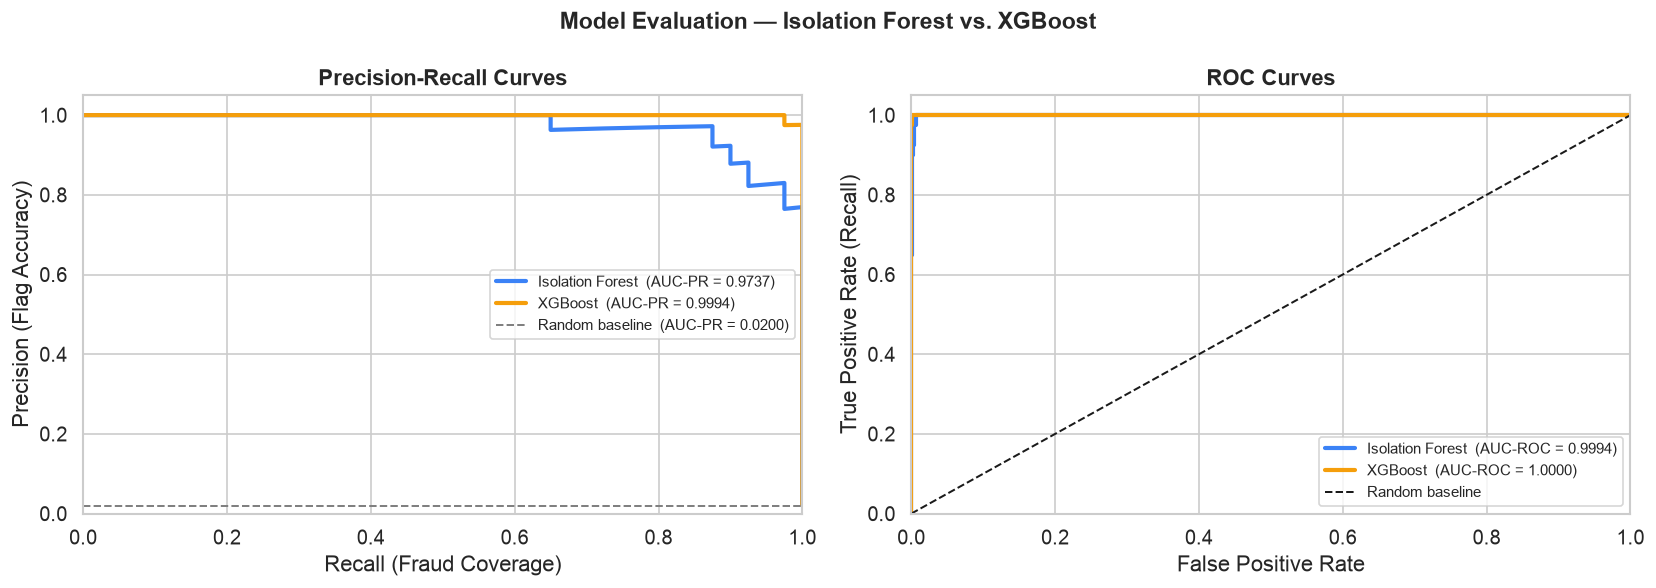

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: PR curves ────────────────────────────────────────────────────────
ax = axes[0]
for name, scores, colour in [
    ('Isolation Forest', if_scores,  IF_COLOUR),
    ('XGBoost',          xgb_scores, XGB_COLOUR),
]:
    prec, rec, thresh = precision_recall_curve(y_test, scores)
    auc_pr = average_precision_score(y_test, scores)
    ax.plot(rec, prec, color=colour, linewidth=2.5,
            label=f'{name}  (AUC-PR = {auc_pr:.4f})')

ax.axhline(baseline_auc_pr, color='grey', linestyle='--', linewidth=1.2,
           label=f'Random baseline  (AUC-PR = {baseline_auc_pr:.4f})')
ax.set_xlabel('Recall (Fraud Coverage)')
ax.set_ylabel('Precision (Flag Accuracy)')
ax.set_title('Precision-Recall Curves', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

# ── Right: ROC curves ──────────────────────────────────────────────────────
ax = axes[1]
for name, scores, colour in [
    ('Isolation Forest', if_scores,  IF_COLOUR),
    ('XGBoost',          xgb_scores, XGB_COLOUR),
]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc_roc     = roc_auc_score(y_test, scores)
    ax.plot(fpr, tpr, color=colour, linewidth=2.5,
            label=f'{name}  (AUC-ROC = {auc_roc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curves', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

plt.suptitle('Model Evaluation — Isolation Forest vs. XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Score Distributions

How well does each model separate the two classes? Wider separation = easier to choose a threshold that catches fraud without flooding analysts with false positives.

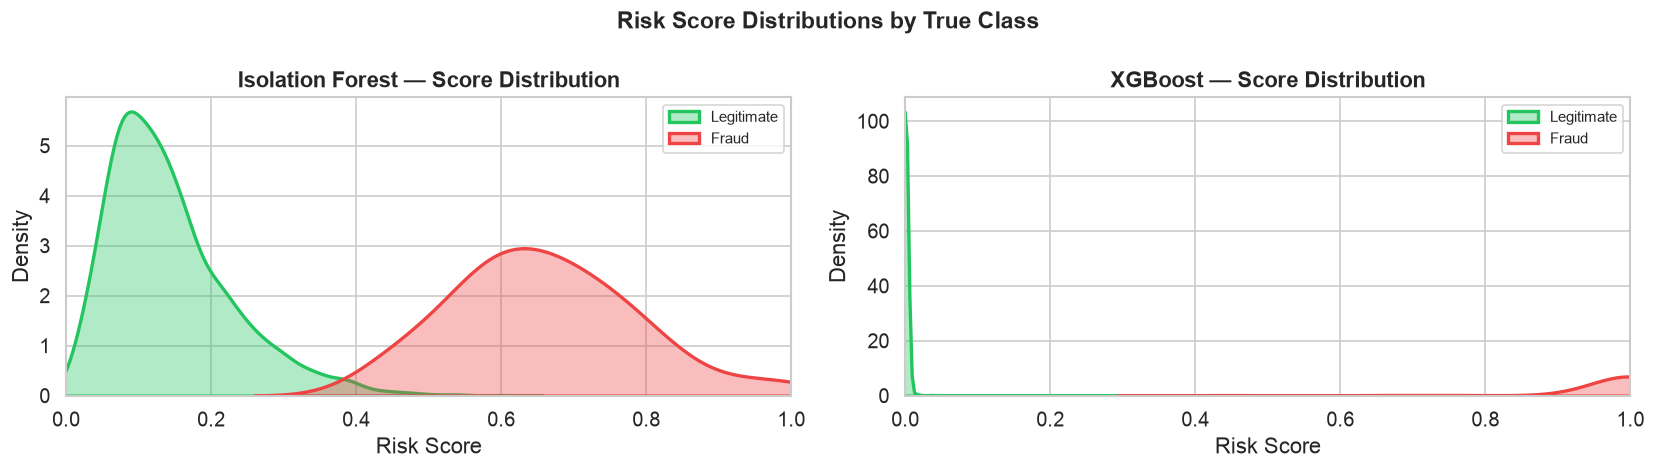

Isolation Forest      mean separation: 0.517  (fraud mean 0.659 vs legit mean 0.143)
XGBoost               mean separation: 0.966  (fraud mean 0.967 vs legit mean 0.001)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (name, scores, colour) in zip(axes, [
    ('Isolation Forest', if_scores,  IF_COLOUR),
    ('XGBoost',          xgb_scores, XGB_COLOUR),
]):
    for cls, cls_colour, label in [
        (0, LEGIT_CLR,  'Legitimate'),
        (1, FRAUD_CLR,  'Fraud'),
    ]:
        sns.kdeplot(
            scores[y_test == cls],
            ax=ax, color=cls_colour, fill=True, alpha=0.35,
            linewidth=2, label=label,
        )
    ax.set_xlabel('Risk Score')
    ax.set_ylabel('Density')
    ax.set_title(f'{name} — Score Distribution', fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim([0, 1])

plt.suptitle('Risk Score Distributions by True Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Separation metric: difference in mean scores between classes
for name, scores in [('Isolation Forest', if_scores), ('XGBoost', xgb_scores)]:
    sep = scores[y_test == 1].mean() - scores[y_test == 0].mean()
    print(f'{name:20s}  mean separation: {sep:.3f}  '
          f'(fraud mean {scores[y_test==1].mean():.3f} vs legit mean {scores[y_test==0].mean():.3f})')

---
## 7. Precision and Recall vs. Threshold

In production, the fraud threshold is a business decision: a stricter threshold increases precision (fewer false positives for analysts) at the cost of lower recall (more fraud missed). This plot shows that tradeoff for each model.

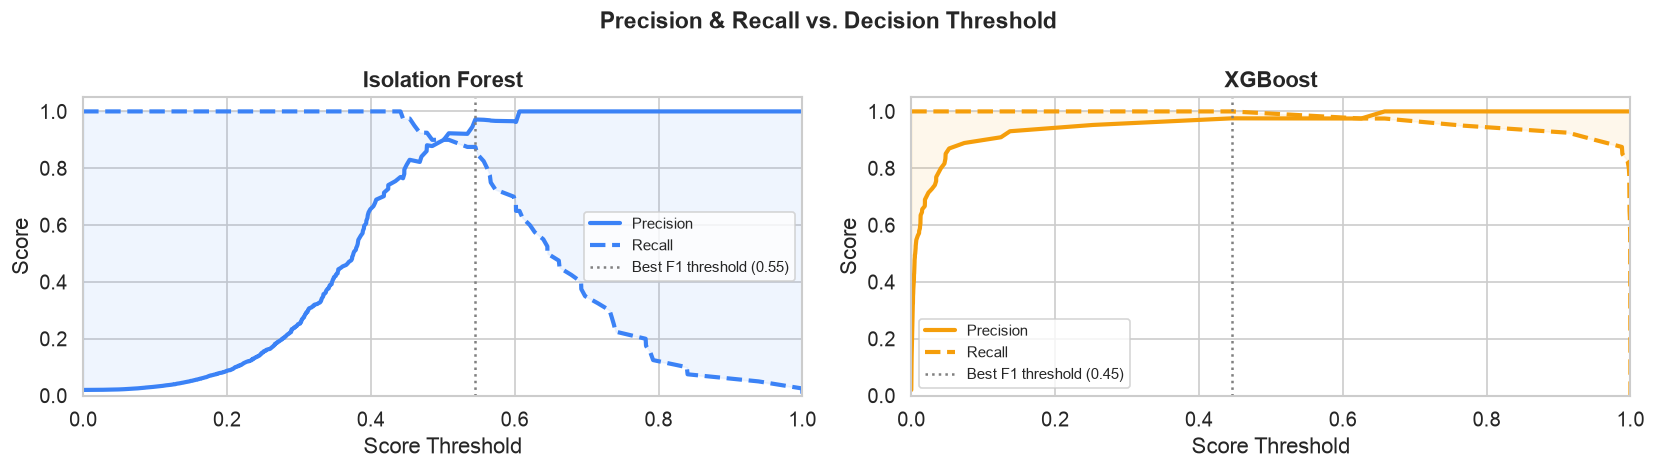

Best F1 thresholds:
  Isolation Forest      threshold=0.545  precision=0.972  recall=0.875  F1=0.921
  XGBoost               threshold=0.445  precision=0.976  recall=1.000  F1=0.988


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (name, scores, colour) in zip(axes, [
    ('Isolation Forest', if_scores,  IF_COLOUR),
    ('XGBoost',          xgb_scores, XGB_COLOUR),
]):
    prec, rec, thresh = precision_recall_curve(y_test, scores)
    # precision_recall_curve appends a final point at threshold=1; align lengths
    thresh = np.append(thresh, 1.0)

    ax.plot(thresh, prec, color=colour,      linewidth=2.5, label='Precision')
    ax.plot(thresh, rec,  color=colour,      linewidth=2.5, label='Recall',
            linestyle='--')
    ax.fill_between(thresh, prec, rec, alpha=0.08, color=colour)

    # Mark the F1-maximising threshold
    f1_scores = 2 * prec * rec / np.where((prec + rec) == 0, 1e-9, prec + rec)
    best_idx  = np.argmax(f1_scores)
    ax.axvline(thresh[best_idx], color='grey', linestyle=':', linewidth=1.5,
               label=f'Best F1 threshold ({thresh[best_idx]:.2f})')

    ax.set_xlabel('Score Threshold')
    ax.set_ylabel('Score')
    ax.set_title(f'{name}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])

plt.suptitle('Precision & Recall vs. Decision Threshold', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Best F1 thresholds:')
for name, scores in [('Isolation Forest', if_scores), ('XGBoost', xgb_scores)]:
    prec, rec, thresh = precision_recall_curve(y_test, scores)
    thresh = np.append(thresh, 1.0)
    f1 = 2 * prec * rec / np.where((prec + rec) == 0, 1e-9, prec + rec)
    best = np.argmax(f1)
    print(f'  {name:20s}  threshold={thresh[best]:.3f}  '
          f'precision={prec[best]:.3f}  recall={rec[best]:.3f}  F1={f1[best]:.3f}')

---
## 8. Feature Importance Comparison

Both models can tell us which features drive predictions — but in different ways:
- **Isolation Forest**: SHAP values (post-hoc, consistent with production explanations)
- **XGBoost**: native `feature_importances_` (gain-based), fast and built-in

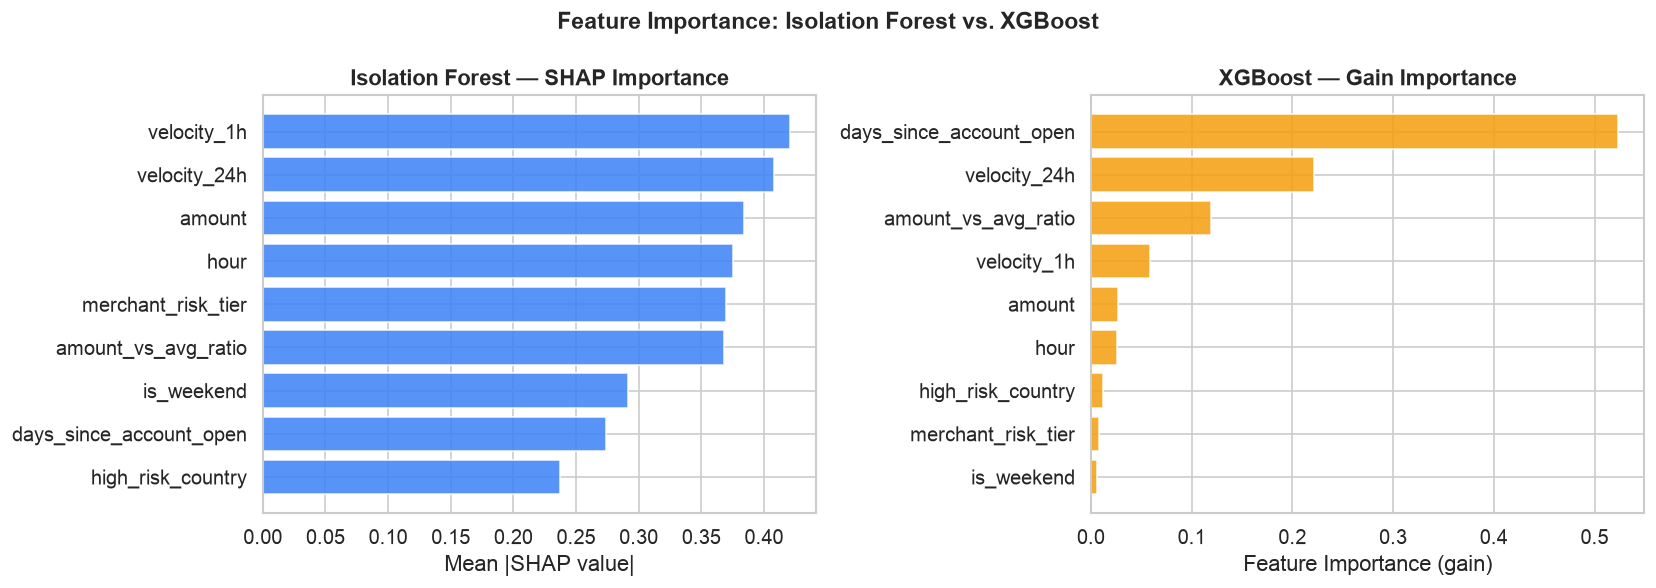

Spearman rank correlation between importance rankings: ρ = 0.233  (p = 0.546)
(ρ close to 1 = models agree on which features matter most)


In [9]:
import shap

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Isolation Forest: SHAP mean |value| ────────────────────────────────────
explainer_if = shap.TreeExplainer(if_model)
# Use a sample to keep this fast (SHAP on IF can be slow)
sample_idx   = np.random.RandomState(42).choice(len(X_test_if), size=min(500, len(X_test_if)), replace=False)
shap_vals    = explainer_if.shap_values(X_test_if[sample_idx])
mean_abs_shap = np.abs(shap_vals).mean(axis=0)

order_if = np.argsort(mean_abs_shap)
axes[0].barh(
    [feature_names[i] for i in order_if],
    mean_abs_shap[order_if],
    color=IF_COLOUR, edgecolor='white', alpha=0.85,
)
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('Isolation Forest — SHAP Importance', fontweight='bold')

# ── XGBoost: gain-based feature importance ──────────────────────────────────
importances = xgb_model.feature_importances_
order_xgb   = np.argsort(importances)
axes[1].barh(
    [feature_names[i] for i in order_xgb],
    importances[order_xgb],
    color=XGB_COLOUR, edgecolor='white', alpha=0.85,
)
axes[1].set_xlabel('Feature Importance (gain)')
axes[1].set_title('XGBoost — Gain Importance', fontweight='bold')

plt.suptitle('Feature Importance: Isolation Forest vs. XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Rank correlation
from scipy.stats import spearmanr
# Map both importance vectors to the same feature ordering
if_rank  = pd.Series(mean_abs_shap, index=feature_names).rank(ascending=False)
xgb_rank = pd.Series(importances,   index=feature_names).rank(ascending=False)
rho, pval = spearmanr(if_rank, xgb_rank)
print(f'Spearman rank correlation between importance rankings: ρ = {rho:.3f}  (p = {pval:.3f})')
print('(ρ close to 1 = models agree on which features matter most)')

---
## 9. Calibration Check

A well-calibrated model's score actually reflects a probability. XGBoost outputs calibrated probabilities; the Isolation Forest's normalised score is a pseudo-probability. We check this with a reliability diagram.

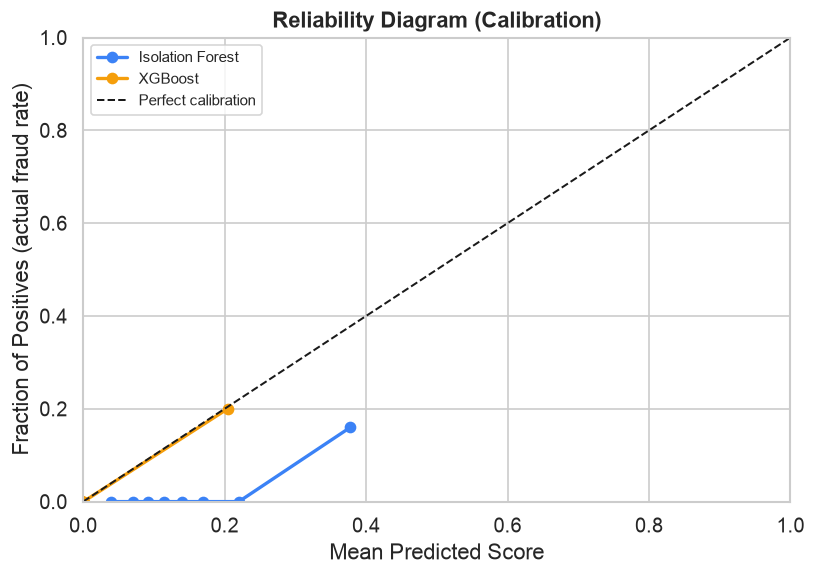

Interpretation:
  Points on the diagonal = scores are well-calibrated probabilities.
  Points above diagonal  = model under-predicts risk (conservative).
  Points below diagonal  = model over-predicts risk (aggressive).

  XGBoost scores are direct fraud probabilities and tend to be better calibrated.
  Isolation Forest scores are normalised anomaly magnitudes, not probabilities.
  IF scores are useful for ranking but should not be interpreted as P(fraud).


In [10]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 5))

for name, scores, colour in [
    ('Isolation Forest', if_scores,  IF_COLOUR),
    ('XGBoost',          xgb_scores, XGB_COLOUR),
]:
    # Use fewer bins for IF since scores may cluster at extremes
    n_bins = 8 if 'Forest' in name else 10
    frac_pos, mean_pred = calibration_curve(y_test, scores, n_bins=n_bins, strategy='quantile')
    ax.plot(mean_pred, frac_pos, 'o-', color=colour, linewidth=2, markersize=6, label=name)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Score')
ax.set_ylabel('Fraction of Positives (actual fraud rate)')
ax.set_title('Reliability Diagram (Calibration)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  Points on the diagonal = scores are well-calibrated probabilities.')
print('  Points above diagonal  = model under-predicts risk (conservative).')
print('  Points below diagonal  = model over-predicts risk (aggressive).')
print()
print('  XGBoost scores are direct fraud probabilities and tend to be better calibrated.')
print('  Isolation Forest scores are normalised anomaly magnitudes, not probabilities.')
print('  IF scores are useful for ranking but should not be interpreted as P(fraud).')

---
## 10. Operational Impact: Workload vs. Fraud Caught

In practice, an analyst team can only review N transactions per day. This plot shows how many fraud cases each model catches at different review volumes — a direct measure of operational value.

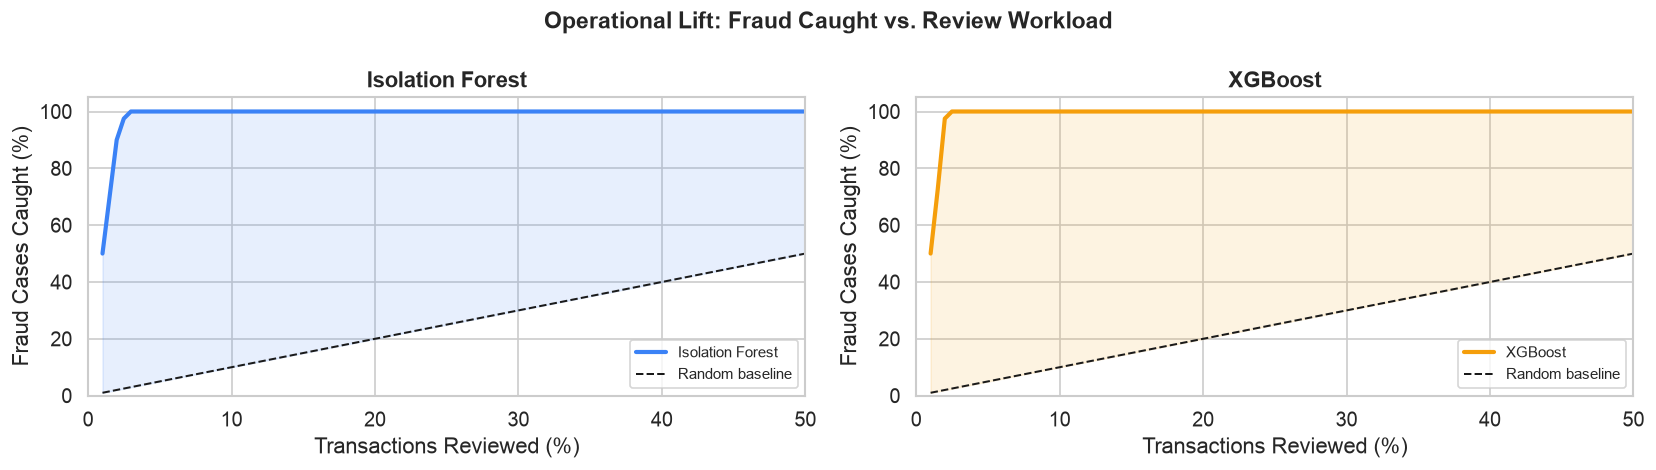

Fraud captured at different review workloads:

Model                  |    Review 5% |   Review 10% |   Review 20%
-----------------------------------------------------------------
Isolation Forest       |       100.0% |       100.0% |       100.0%
XGBoost                |       100.0% |       100.0% |       100.0%


In [11]:
n_test    = len(y_test)
n_fraud   = int(y_test.sum())
review_pcts = np.linspace(0.01, 0.50, 100)   # review 1%–50% of transactions
review_ns   = (review_pcts * n_test).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax_idx, (name, scores, colour) in enumerate([
    ('Isolation Forest', if_scores,  IF_COLOUR),
    ('XGBoost',          xgb_scores, XGB_COLOUR),
]):
    # Sort by descending score; flag top-N as fraud
    ranked = np.argsort(scores)[::-1]
    cumulative_fraud = np.cumsum(y_test.values[ranked])

    fraud_caught_pct = [cumulative_fraud[n - 1] / n_fraud * 100 for n in review_ns]
    random_baseline  = review_pcts * 100   # random flag → proportional catch

    axes[ax_idx].plot(review_pcts * 100, fraud_caught_pct,
                      color=colour, linewidth=2.5, label=name)
    axes[ax_idx].plot(review_pcts * 100, random_baseline,
                      'k--', linewidth=1.2, label='Random baseline')
    axes[ax_idx].fill_between(review_pcts * 100, fraud_caught_pct, random_baseline,
                               alpha=0.12, color=colour)
    axes[ax_idx].set_xlabel('Transactions Reviewed (%)')
    axes[ax_idx].set_ylabel('Fraud Cases Caught (%)')
    axes[ax_idx].set_title(f'{name}', fontweight='bold')
    axes[ax_idx].legend(fontsize=9)
    axes[ax_idx].set_xlim([0, 50])
    axes[ax_idx].set_ylim([0, 105])

plt.suptitle('Operational Lift: Fraud Caught vs. Review Workload', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Lift at 5% and 10% review rates
print('Fraud captured at different review workloads:\n')
print(f'{"Model":22s} | {"Review 5%":>12} | {"Review 10%":>12} | {"Review 20%":>12}')
print('-' * 65)
for name, scores in [('Isolation Forest', if_scores), ('XGBoost', xgb_scores)]:
    ranked = np.argsort(scores)[::-1]
    cumf   = np.cumsum(y_test.values[ranked])
    r5  = cumf[int(0.05 * n_test) - 1] / n_fraud * 100
    r10 = cumf[int(0.10 * n_test) - 1] / n_fraud * 100
    r20 = cumf[int(0.20 * n_test) - 1] / n_fraud * 100
    print(f'{name:22s} | {r5:>11.1f}% | {r10:>11.1f}% | {r20:>11.1f}%')

---
## 11. Summary and Recommendation

In [12]:
if_auc_pr   = average_precision_score(y_test, if_scores)
xgb_auc_pr  = average_precision_score(y_test, xgb_scores)
if_auc_roc  = roc_auc_score(y_test, if_scores)
xgb_auc_roc = roc_auc_score(y_test, xgb_scores)

if_ranked  = np.argsort(if_scores)[::-1]
xgb_ranked = np.argsort(xgb_scores)[::-1]
if_r10  = np.cumsum(y_test.values[if_ranked])[int(0.10 * n_test) - 1] / n_fraud * 100
xgb_r10 = np.cumsum(y_test.values[xgb_ranked])[int(0.10 * n_test) - 1] / n_fraud * 100

print('=' * 65)
print('SUMMARY')
print('=' * 65)
print(f"""
METRIC COMPARISON
  {'Metric':25s}  {'Isolation Forest':>18}  {'XGBoost':>10}
  {'─'*55}
  {'AUC-PR (primary)':25s}  {if_auc_pr:>18.4f}  {xgb_auc_pr:>10.4f}
  {'AUC-ROC':25s}  {if_auc_roc:>18.4f}  {xgb_auc_roc:>10.4f}
  {'Fraud caught @ 10% review':25s}  {if_r10:>17.1f}%  {xgb_r10:>9.1f}%

WHEN TO USE EACH

  Isolation Forest (unsupervised)
  ├─ No fraud labels required — deploy immediately on new data streams
  ├─ Detects novel / previously unseen fraud patterns
  ├─ More robust when fraud labels are noisy or missing
  └─ SHAP explanations align with what the production system already uses

  XGBoost (supervised)
  ├─ Higher AUC-PR when quality labels are available
  ├─ Calibrated probabilities → interpretable risk scores (e.g. P(fraud) = 0.87)
  ├─ Can encode domain knowledge via feature engineering
  └─ Better operational lift: catches more fraud per analyst review hour

PRODUCTION RECOMMENDATION
  Run both in parallel. Use the Isolation Forest to catch novel anomalies
  (unseen fraud typologies) and XGBoost for known-pattern high-precision
  flagging. Ensemble by taking max(IF_score, XGB_score) as the final risk
  score, which preserves the strengths of both.
""")
print('=' * 65)

SUMMARY

METRIC COMPARISON
  Metric                       Isolation Forest     XGBoost
  ───────────────────────────────────────────────────────
  AUC-PR (primary)                       0.9737      0.9994
  AUC-ROC                                0.9994      1.0000
  Fraud caught @ 10% review              100.0%      100.0%

WHEN TO USE EACH

  Isolation Forest (unsupervised)
  ├─ No fraud labels required — deploy immediately on new data streams
  ├─ Detects novel / previously unseen fraud patterns
  ├─ More robust when fraud labels are noisy or missing
  └─ SHAP explanations align with what the production system already uses

  XGBoost (supervised)
  ├─ Higher AUC-PR when quality labels are available
  ├─ Calibrated probabilities → interpretable risk scores (e.g. P(fraud) = 0.87)
  ├─ Can encode domain knowledge via feature engineering
  └─ Better operational lift: catches more fraud per analyst review hour

PRODUCTION RECOMMENDATION
  Run both in parallel. Use the Isolation Forest to 